# RLlib PPO & SAC на InstantContinuousPipelineEnv

Сравнение с Tianshou: те же алгоритмы (PPO, SAC), та же среда, та же архитектура сетей (`[256, 256]` + LayerNorm), мониторинг градиентов.

Цель — проверить, проблема с взрывом градиентов в алгоритмах или в библиотеке.

In [20]:
import sys
import os
sys.path.insert(0, os.getcwd())

import ray
import numpy as np
from ray.rllib.algorithms.ppo import PPOConfig
from ray.rllib.algorithms.sac import SACConfig
from ray.tune.registry import register_env
from ray.rllib.core.rl_module.default_model_config import DefaultModelConfig

from hpo_rl.environments.instant_continuous_pipeline_env import InstantContinuousPipelineEnv
from hpo_rl.backends.function import OptimizationBenchmarkBackend
from hpo_rl.backends.sequential import SequentialBackend
import torch

## Общие утилиты

1. **Фабрика среды** — создаёт `InstantContinuousPipelineEnv` с `SequentialBackend` (rastrigin + rosenbrock + schwefel, 2D).  
2. **Gradient hook** — навешивается в RLlib-callback после каждого `on_train_result`, собирает статистику по градиентам аналогично `GradientMonitorMixin` из Tianshou-пайплайна.

In [21]:
# ── Конфигурация среды (одинаковая для PPO и SAC) ──────────────────────

ENV_CONFIG = {
    "max_delta_frac": 0.05,
    "max_steps": 200,
    "history_window": 3,
    "reward_mode": "ternary",
}

BACKEND_SPECS = [
    {"function": "rastrigin",  "dimensions": 2},
    {"function": "rosenbrock", "dimensions": 2},
    {"function": "schwefel",   "dimensions": 2},
]


def _make_backend() -> SequentialBackend:
    """Создаёт SequentialBackend(shuffle) из списка бенчмарков."""
    backends = [
        OptimizationBenchmarkBackend(
            function_name=spec["function"],
            dimensions=spec["dimensions"],
            maximize=False,
        )
        for spec in BACKEND_SPECS
    ]
    return SequentialBackend(backends=backends, mode="shuffle")


def _make_hp_space(backend: SequentialBackend) -> dict:
    """Генерирует hp_space по merged bounds первого child бэкенда."""
    child = backend.backends[0]
    lo, hi = child.bounds
    dims = child.dimensions
    return {
        f"x{i}": {"type": "float", "values": [lo, hi], "log": False}
        for i in range(dims)
    }


class _AutoSwitchEnv(InstantContinuousPipelineEnv):
    """Обёртка, которая переключает SequentialBackend на каждом reset().

    В Tianshou это делает контроллер (``backend.next_backend()`` раз в эпоху).
    В RLlib контроллера нет — поэтому переключаем бэкенд прямо в env.
    """

    def reset(self, seed=None, options=None):
        if isinstance(self.backend, SequentialBackend):
            self.backend.next_backend()
        return super().reset(seed=seed, options=options)


def env_creator(config: dict) -> _AutoSwitchEnv:
    """Фабрика среды для register_env (Ray Tune)."""
    backend = _make_backend()
    hp_space = _make_hp_space(backend)
    env_kwargs = {**ENV_CONFIG, **(config or {})}
    return _AutoSwitchEnv(
        hp_space=hp_space,
        backend=backend,
        **env_kwargs,
    )


register_env("HPO-ContinuousPipeline-v0", env_creator)

In [22]:
# ── RLlib Callback для мониторинга градиентов ──────────────────────────
from ray.rllib.callbacks.callbacks import RLlibCallback
import threading


class GradientMonitorCallback(RLlibCallback):
    """Логирует статистику градиентов через backward hooks."""

    def __init__(self, log_interval: int = 5):
        super().__init__()
        self._log_interval = log_interval
        self._step_counter = 0
        self._hooks_installed = False
        self._grad_accum: dict[str, list[float]] = {}  # name → list of norms
        self._lock = threading.Lock()

    def _try_install_hooks(self, algorithm) -> bool:
        """Пытаемся найти learner и повесить hooks. Возвращает True при успехе."""
        if self._hooks_installed:
            return True

        # RLlib 2.x: разные версии используют разные атрибуты
        learner = None
        lg = algorithm.learner_group
        for attr in ("_learner", "_local_learner", "_learners"):
            obj = getattr(lg, attr, None)
            if obj is None:
                continue
            if isinstance(obj, (list, tuple)) and len(obj) > 0:
                learner = obj[0]
                break
            if hasattr(obj, "module"):
                learner = obj
                break

        if learner is None:
            return False

        count = 0
        for module_id, rl_module in learner.module.items():
            if not hasattr(rl_module, "named_parameters"):
                continue
            for name, param in rl_module.named_parameters():
                if not param.requires_grad:
                    continue
                key = f"{module_id}/{name}"
                def _hook(grad, k=key):
                    with self._lock:
                        self._grad_accum.setdefault(k, []).append(grad.norm().item())
                param.register_hook(_hook)
                count += 1

        self._hooks_installed = True
        print(f"[GradMonitor] Hooks on {count} params")
        return True

    def on_train_result(self, *, algorithm, metrics_logger=None, result, **kwargs):
        if not self._hooks_installed:
            if not self._try_install_hooks(algorithm):
                # Не удалось — пробуем на следующей итерации
                return

        self._step_counter += 1

        with self._lock:
            snapshot = dict(self._grad_accum)
            self._grad_accum.clear()

        if not snapshot:
            return

        all_norms = [float(np.mean(norms)) for norms in snapshot.values()]
        n_bwd = len(next(iter(snapshot.values())))

        result.setdefault("custom_metrics", {}).update({
            "grad/total_norm_mean": float(np.mean(all_norms)),
            "grad/total_norm_max": float(np.max(all_norms)),
            "grad/num_backward_passes": n_bwd,
        })

        if self._step_counter % self._log_interval == 0:
            print(f"  [grad] iter {self._step_counter} | {n_bwd} bwd | "
                  f"norm={np.mean(all_norms):.4f} max={np.max(all_norms):.4f}")

In [23]:
# ── Утилита для запуска обучения и печати результатов ──────────────────

def _find(d, *keys):
    """Ищет первый найденный ключ в nested dict (рекурсивно)."""
    if not isinstance(d, dict):
        return None
    for k in keys:
        if k in d:
            return d[k]
    for v in d.values():
        r = _find(v, *keys)
        if r is not None:
            return r
    return None


def train_and_report(algo, n_iters: int = 50, dump_first: bool = False):
    """Обучает n_iters итераций, печатает 1 строку на итерацию.
    
    dump_first=True — печатает ТОЛЬКО ключи верхнего уровня result dict (iter 1).
    """
    best_reward = float("-inf")
    for i in range(1, n_iters + 1):
        result = algo.train()

        if dump_first and i == 1:
            print(f"TOP KEYS: {list(result.keys())}")
            for section in ("env_runners", "learners"):
                sub = result.get(section, {})
                if isinstance(sub, dict):
                    # Для learners — показать ключи вложенного dict
                    for k, v in sub.items():
                        if isinstance(v, dict):
                            print(f"  {section}/{k}: {list(v.keys())}")
                        else:
                            print(f"  {section}/{k} = {v}")

        # ── Episode metrics ──
        ep_ret = _find(result, "episode_return_mean", "episode_reward_mean")
        ep_len = _find(result, "episode_len_mean", "episode_length_mean")
        ep_ret = float(ep_ret) if ep_ret is not None else float("nan")
        ep_len = float(ep_len) if ep_len is not None else float("nan")

        if not np.isnan(ep_ret) and ep_ret > best_reward:
            best_reward = ep_ret

        # ── Loss (deep search) ──
        total = _find(result, "total_loss")
        actor = _find(result, "actor_loss", "policy_loss")
        critic = _find(result, "critic_loss", "qf_loss", "vf_loss")
        alpha = _find(result, "alpha_loss")

        parts = []
        if total is not None:  parts.append(f"L={total:.3f}")
        if actor is not None:  parts.append(f"π={actor:.3f}")
        if critic is not None: parts.append(f"Q={critic:.3f}")
        if alpha is not None:  parts.append(f"α={alpha:.3f}")
        loss_s = " ".join(parts) if parts else "---"

        # ── Grad stats ──
        cm = result.get("custom_metrics", {})
        gm = cm.get("grad/total_norm_mean")
        grad_s = f"|g|={gm:.3f}" if gm is not None else ""

        ret_s = f"{ep_ret:+.1f}" if not np.isnan(ep_ret) else "---"
        len_s = f"{ep_len:.0f}" if not np.isnan(ep_len) else "---"
        best_s = f"{best_reward:+.1f}" if best_reward > float("-inf") else "---"

        print(f"[{i:3d}/{n_iters}] ret={ret_s}  len={len_s}  {loss_s}  best={best_s}  {grad_s}")

    print(f"\n>>> Done. Best={best_reward:+.4f}")
    return algo


def run_inference(algo, n_episodes: int = 3):
    """Прогоняет несколько эпизодов в inference-режиме, печатает результат и визуализирует траекторию."""
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    from matplotlib.collections import LineCollection
    from mpl_toolkits.mplot3d.art3d import Line3DCollection
    from matplotlib.ticker import MaxNLocator, ScalarFormatter

    env = env_creator({})
    
    has_rl_module = hasattr(algo, "get_module")
    if has_rl_module:
        rl_module = algo.get_module()
        if hasattr(rl_module, "eval"):
            rl_module.eval()

    all_episodes_data = []
            
    for ep in range(n_episodes):
        obs, info = env.reset()
        active_child = env.backend.current_backend
        func_name = getattr(active_child, "function_name", "unknown")
        total_reward = 0.0
        done = False
        history = []

        while not done:
            if has_rl_module:
                with torch.no_grad():
                    obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
                    out = rl_module.forward_inference({"obs": obs_t})
                    action_dim = env.action_space.shape[0]
                    action = out["action_dist_inputs"][0, :action_dim].cpu().numpy()
            else:
                action = algo.compute_single_action(obs, explore=False)
                
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            done = terminated or truncated
            step_config = info.get("current_config", info.get("best_config", {}))
            step_metric = info.get("current_metric", info.get("best_metric", float("nan")))
            history.append((dict(step_config), step_metric))

        all_episodes_data.append((history, active_child, func_name))
        print(
            f"[ep {ep+1} | {func_name}] reward={total_reward:+.4f}  "
            f"best_metric={info.get('best_metric', float('nan')):.6f}  "
            f"best_config={info.get('best_config', {})}"
        )

    env.close()

    # ── Визуализация ──
    original_plasma = plt.get_cmap("plasma")
    truncated_plasma = mcolors.LinearSegmentedColormap.from_list(
        "truncated_plasma", original_plasma(np.linspace(0, 0.85, 256))
    )
    surface_cache: dict[str, tuple] = {}

    def _get_surface(child_backend):
        fname = getattr(child_backend, "function_name", "unknown")
        if fname in surface_cache:
            return surface_cache[fname]
        lo, hi = child_backend.bounds
        grid = np.linspace(lo, hi, 100)
        X0, X1 = np.meshgrid(grid, grid)
        Z = np.zeros_like(X0)
        for ii in range(X0.shape[0]):
            for jj in range(X0.shape[1]):
                Z[ii, jj] = child_backend.evaluate({"x0": X0[ii, jj], "x1": X1[ii, jj]})
        surface_cache[fname] = (X0, X1, Z)
        return X0, X1, Z

    for ep_idx, (history, child, func_name) in enumerate(all_episodes_data):
        if not history:
            continue
        x0_vals = np.array([h[0].get("x0", 0.0) for h in history])
        x1_vals = np.array([h[0].get("x1", 0.0) for h in history])
        metrics = np.array([h[1] for h in history])
        n_points = len(x0_vals)
        colors = np.linspace(0, 1, n_points)
        X0, X1, Z = _get_surface(child)

        fig, (ax1, _) = plt.subplots(1, 2, figsize=(16, 7))
        ax1.contourf(X0, X1, Z, levels=20, cmap="viridis", alpha=0.15)
        contour = ax1.contour(X0, X1, Z, levels=20, cmap="viridis", alpha=0.3)
        ax1.clabel(contour, inline=True, fontsize=8)
        points = np.column_stack([x0_vals, x1_vals]).reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap=truncated_plasma, array=colors, linewidth=2.5, zorder=3)
        ax1.add_collection(lc)
        ax1.scatter(x0_vals, x1_vals, c=colors, cmap=truncated_plasma, s=25, edgecolors="none", alpha=0.8, zorder=4)
        ax1.scatter(x0_vals[0], x1_vals[0], c="green", s=100, marker="o", label="Start", zorder=5, edgecolors="white")
        ax1.scatter(x0_vals[-1], x1_vals[-1], c="red", s=120, marker="*", label="End", zorder=5, edgecolors="white")
        best_idx = int(np.argmin(metrics))
        ax1.scatter(x0_vals[best_idx], x1_vals[best_idx], c="cyan", s=150, marker="X", label="Best", zorder=6, edgecolors="black")
        ax1.set_title(f"Episode {ep_idx+1} — {func_name} — 2D Trajectory")
        ax1.set_aspect("equal")
        ax1.legend()

        ax2 = fig.add_subplot(122, projection="3d")
        ax2.plot_surface(X0, X1, Z, cmap="viridis", alpha=0.3, linewidth=0, antialiased=True)
        pts3d = np.column_stack([x0_vals, x1_vals, metrics]).reshape(-1, 1, 3)
        seg3d = np.concatenate([pts3d[:-1], pts3d[1:]], axis=1)
        lc3d = Line3DCollection(seg3d, cmap=truncated_plasma, array=colors, linewidth=3)
        ax2.add_collection3d(lc3d)
        ax2.scatter(x0_vals, x1_vals, metrics, c=colors, cmap=truncated_plasma, s=30, depthshade=False)
        ax2.scatter(x0_vals[0], x1_vals[0], metrics[0], c="green", s=100, marker="o", edgecolors="white")
        ax2.scatter(x0_vals[-1], x1_vals[-1], metrics[-1], c="red", s=130, marker="*", edgecolors="white")
        ax2.scatter(x0_vals[best_idx], x1_vals[best_idx], metrics[best_idx], c="cyan", s=150, marker="X", edgecolors="black")
        ax2.set_title(f"{func_name} — 3D View")
        plt.tight_layout()
        plt.show()

        best_so_far = np.minimum.accumulate(metrics)
        iterations = range(1, n_points + 1)
        fig2, ax3 = plt.subplots(figsize=(10, 6))
        ax3.plot(iterations, metrics, marker="o", markersize=4, linestyle="-", color="blue", alpha=0.3, label=r"$f(x)$")
        ax3.plot(iterations, best_so_far, color="red", linewidth=2, label="Best so far (min)")
        ax3.set_title(f"Episode {ep_idx+1} — {func_name} — Optimization History")
        ax3.set_xlabel("Step")
        ax3.set_ylabel("Objective")
        ax3.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax3.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
        ax3.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
        ax3.legend()
        plt.tight_layout()
        plt.show()

## PPO (Continuous)

Полный аналог `config_continuous_ppo` из `run_experiment.ipynb`:
- **Сеть**: `[256, 256]`, активация `relu` (RLlib не поддерживает LayerNorm из коробки в default model — будет использован `fcnet_hiddens`)
- **gamma**: 0.99, **entropy_coeff**: 0.05, **grad_clip**: 0.5, **lr**: 3e-4
- **GAE lambda**: 0.95, **vf_loss_coeff**: 0.5, **clip_param**: 0.2
- **train_batch**: 4000, **minibatch**: 64, **sgd_iters**: 10
- **num_env_runners**: 4 (вместо 20 — RLlib сам vectorized, каждый runner имеет несколько envs)

In [40]:
# ── PPO Config ─────────────────────────────────────────────────────────

ray.init(ignore_reinit_error=True)

# obs_dim = 2 params + 4 base + 3 * (2+1) history = 15
# action_dim = 2 (continuous, Box[-1,1])

ppo_config = (
    PPOConfig()
    .environment(
        env="HPO-ContinuousPipeline-v0",
        env_config={},
    )
    .env_runners(
        num_env_runners=4,
        num_envs_per_env_runner=5,     # 4*5 = 20 параллельных сред (≈ num_training_envs=20 в Tianshou)
        rollout_fragment_length="auto",
    )
    .training(
        gamma=0.99,
        lambda_=0.95,
        lr=3e-4,
        entropy_coeff=0.05,
        vf_loss_coeff=0.5,
        clip_param=0.2,
        grad_clip=0.1,
        train_batch_size_per_learner=4000,
        minibatch_size=64,
        num_epochs=10,                  # SGD passes per batch (= update_step_num_repetitions)
        use_gae=True,
        use_critic=True,
    )
    .rl_module(
        model_config=DefaultModelConfig(
            fcnet_hiddens=[256, 256],
            fcnet_activation="relu",
            vf_share_layers=False,
        ),
    )
    .learners(num_learners=0)  # 0 = local learner (single GPU/CPU)
    .callbacks(GradientMonitorCallback)
    .reporting(
        min_time_s_per_iteration=0,
        min_sample_timesteps_per_iteration=0,
    )
)

ppo_algo = ppo_config.build_algo()
print("PPO algo built successfully")
_env = env_creator({})
print(f"  observation_space: {_env.observation_space}")
print(f"  action_space:      {_env.action_space}")
_env.close()
del _env

2026-03-05 17:08:27,425	INFO worker.py:1831 -- Calling ray.init() again after it has already been called.
c:\Users\cool4\AppData\Local\Programs\Python\Python312\Lib\site-packages\ray\rllib\algorithms\algorithm.py:527: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
c:\Users\cool4\AppData\Local\Programs\Python\Python312\Lib\site-packages\ray\tune\logger\unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  self._loggers.append(cls(self.config, self.logdir, self.trial))
c:\U

PPO algo built successfully
rastrigin: dims=2, bounds=(-5.12, 5.12), opt=0.000000
rosenbrock: dims=2, bounds=(-1.0, 1.0), opt=0.000000
schwefel: dims=2, bounds=(-500.0, 500.0), opt=0.000000
[SequentialBackend] New shuffle order: schwefel, rastrigin, rosenbrock
SequentialBackend: 3 backends (rastrigin, rosenbrock, schwefel), mode=shuffle
  observation_space: Box(-inf, inf, (15,), float32)
  action_space:      Box(-1.0, 1.0, (2,), float32)


In [41]:
# ── PPO Training ───────────────────────────────────────────────────────
# 1 RLlib iteration ≈ 1 Tianshou epoch (оба собирают 4000 env steps).
# Tianshou: max_epochs=100. Ставим 50 для быстрого теста, можно увеличить.
ppo_algo = train_and_report(ppo_algo, n_iters=15)

[iter   1/15]  ep_return=+4.8950  ep_len=200.0  loss=1.2938  best=+4.8950  gradients_default_optimizer_global_norm=0.8475  cb_grad_max=0.0510
[iter   2/15]  ep_return=+8.2850  ep_len=200.0  loss=0.8862  best=+8.2850  gradients_default_optimizer_global_norm=1.3606  cb_grad_max=0.0561
[iter   3/15]  ep_return=+8.5700  ep_len=200.0  loss=0.5706  best=+8.5700  gradients_default_optimizer_global_norm=1.1738  cb_grad_max=0.0557
[iter   4/15]  ep_return=+7.5400  ep_len=200.0  loss=1.5286  best=+8.5700  gradients_default_optimizer_global_norm=2.2226  cb_grad_max=0.0662
[iter   5/15]  ep_return=+10.3350  ep_len=200.0  loss=1.3669  best=+10.3350  gradients_default_optimizer_global_norm=2.3383  cb_grad_max=0.0599
[iter   6/15]  ep_return=+9.7500  ep_len=200.0  loss=1.0816  best=+10.3350  gradients_default_optimizer_global_norm=1.7446  cb_grad_max=0.0556
[iter   7/15]  ep_return=+10.4500  ep_len=200.0  loss=1.2625  best=+10.4500  gradients_default_optimizer_global_norm=1.4931  cb_grad_max=0.0590
[

rastrigin: dims=2, bounds=(-5.12, 5.12), opt=0.000000
rosenbrock: dims=2, bounds=(-1.0, 1.0), opt=0.000000
schwefel: dims=2, bounds=(-500.0, 500.0), opt=0.000000
[SequentialBackend] New shuffle order: schwefel, rastrigin, rosenbrock
SequentialBackend: 3 backends (rastrigin, rosenbrock, schwefel), mode=shuffle
[SequentialBackend] Epoch 1: switched to 'schwefel'
[Inference ep 1 | schwefel] total_reward=-1418.0394  best_metric=829.460613  best_config={'x0': 38.33659946563819, 'x1': -248.26272939999905}
[SequentialBackend] Epoch 2: switched to 'rastrigin'
[Inference ep 2 | rastrigin] total_reward=-814.0466  best_metric=31.859230  best_config={'x0': 5.12, 'x1': 0.12477510896569655}
[SequentialBackend] Epoch 3: switched to 'rosenbrock'
[Inference ep 3 | rosenbrock] total_reward=-363.7652  best_metric=0.003482  best_config={'x0': 1.0, 'x1': 0.9940988852397056}


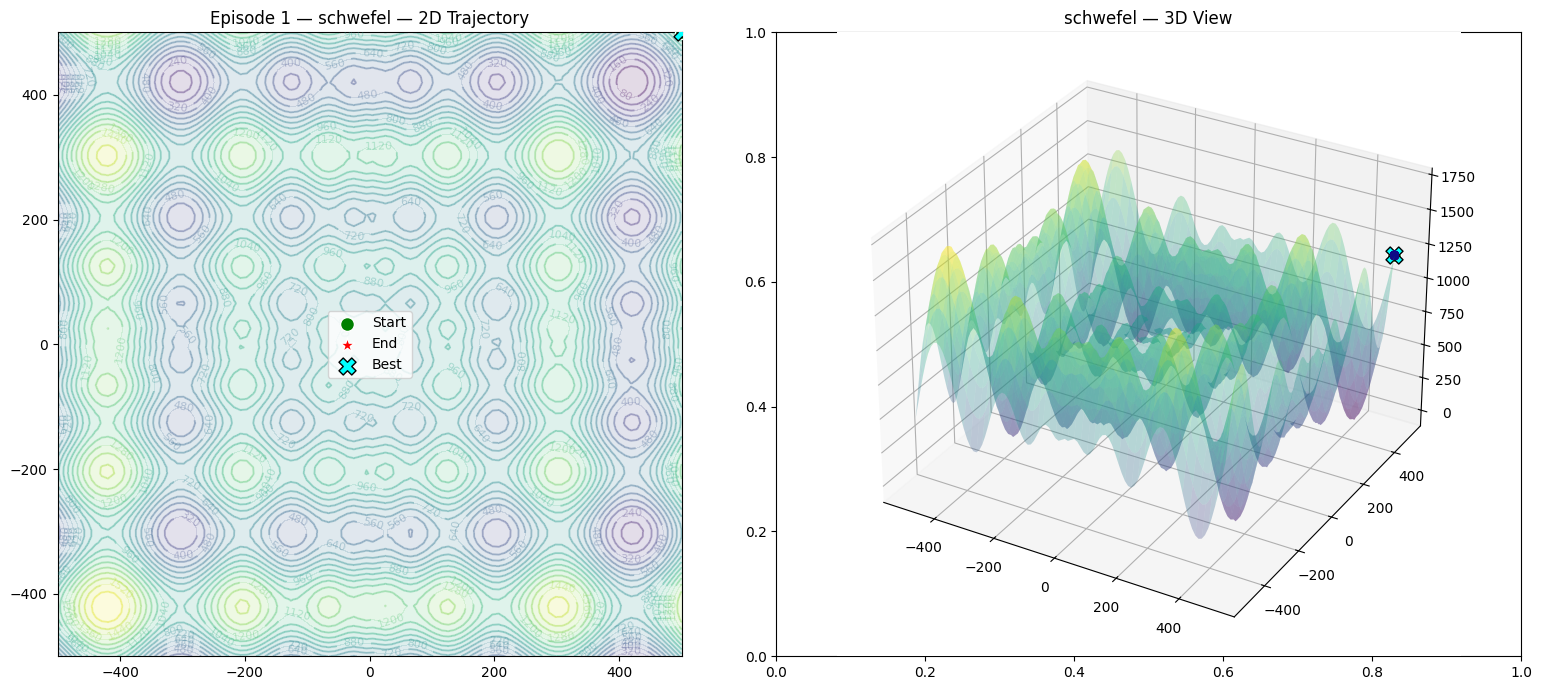

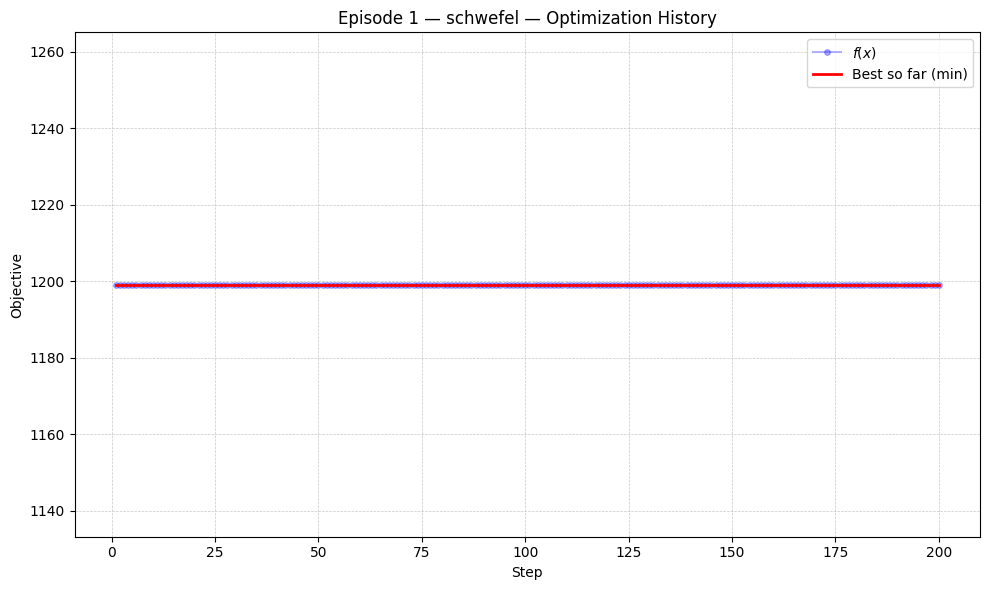

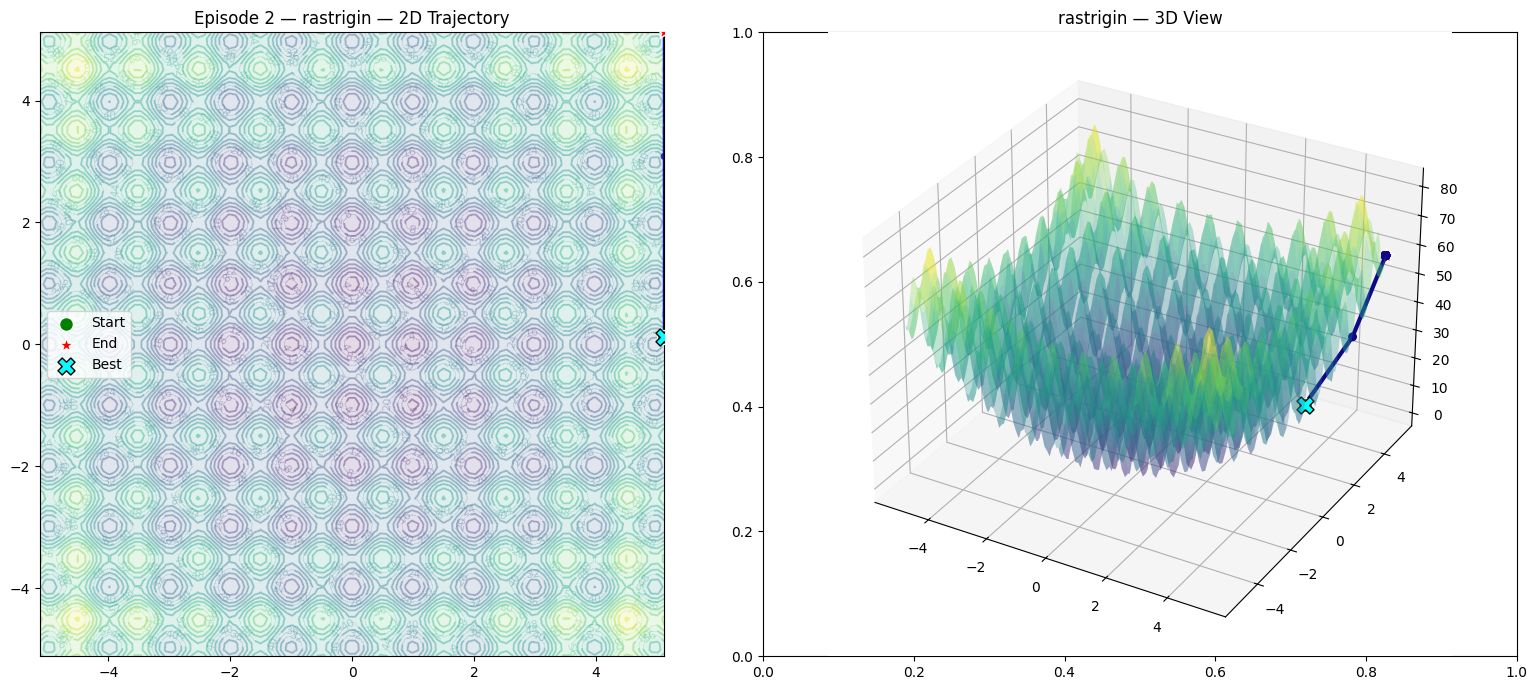

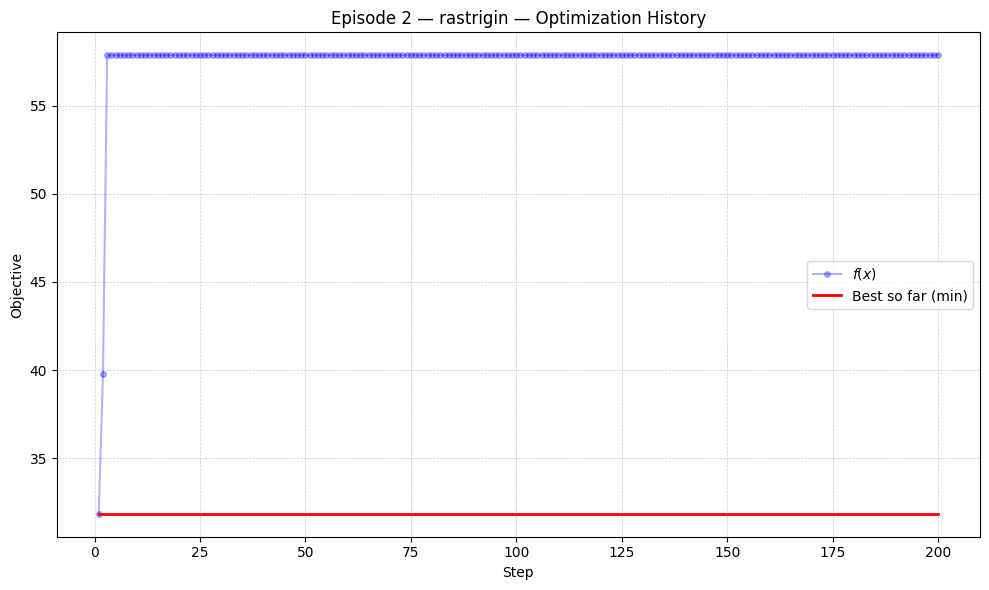

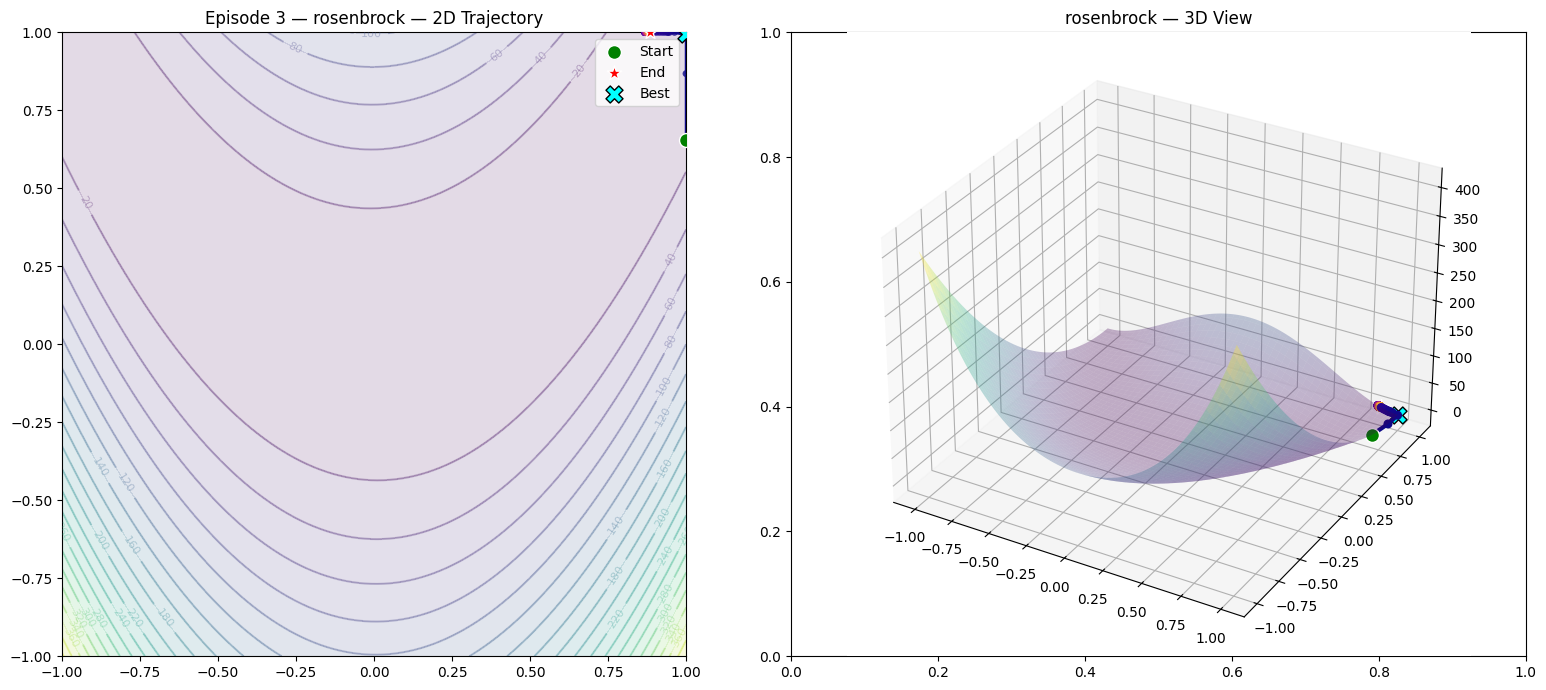

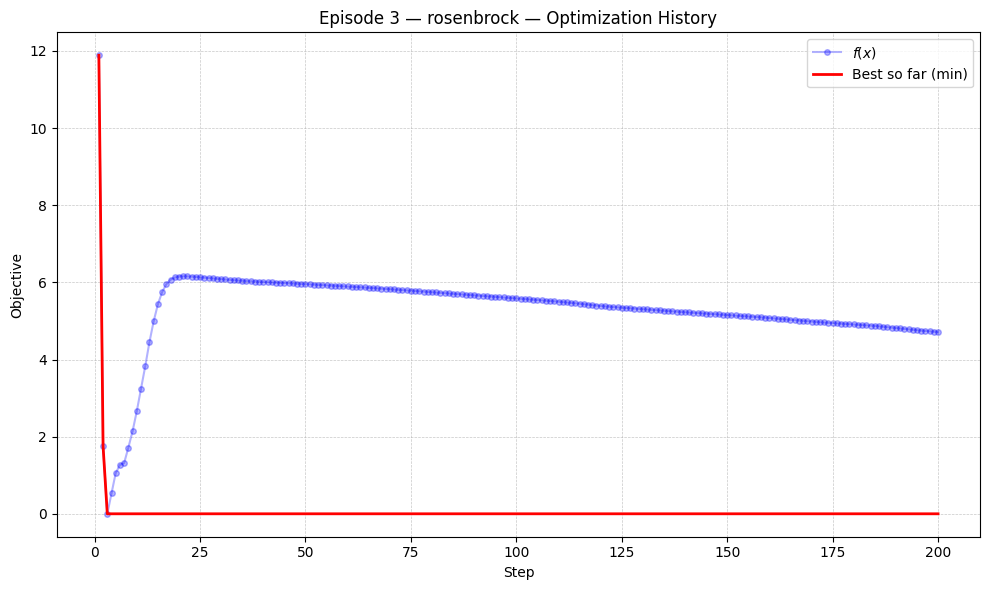

In [42]:
# ── PPO Inference ──────────────────────────────────────────────────────
run_inference(ppo_algo, n_episodes=3)

## SAC (Continuous)

Полный аналог `config_continuous_sac` из `run_experiment.ipynb`:
- **Сеть**: `[256, 256]` (policy и Q-net)
- **gamma**: 0.99, **tau**: 0.005, **auto-alpha** (target_entropy = "auto" → −dim(A) = −2)
- **actor_lr**: 3e-4, **critic_lr**: 3e-4, **alpha_lr**: 3e-4
- **replay_buffer**: 100k, **train_batch**: 256, **n_step**: 1
- **num_env_runners**: 4 × 5 = 20 параллельных сред

In [43]:
# ── SAC Config ─────────────────────────────────────────────────────────

sac_config = (
    SACConfig()
    .environment(
        env="HPO-ContinuousPipeline-v0",
        env_config={},
    )
    .env_runners(
        num_env_runners=4,
        num_envs_per_env_runner=5,     # 4*5 = 20 параллельных сред
        rollout_fragment_length=1,
    )
    .training(
        gamma=0.99,
        tau=0.005,
        initial_alpha=1.0,
        target_entropy="auto",           # → -dim(A) = -2
        actor_lr=3e-4,
        critic_lr=3e-4,
        alpha_lr=3e-4,
        n_step=1,
        train_batch_size_per_learner=256,
        twin_q=True,
        replay_buffer_config={
            "type": "PrioritizedEpisodeReplayBuffer",
            "capacity": 100_000,
        },
        num_steps_sampled_before_learning_starts=2000,
        grad_clip=0.5,
    )
    .rl_module(
        model_config=DefaultModelConfig(
            fcnet_hiddens=[256, 256],
            fcnet_activation="relu",
        ),
    )
    .learners(num_learners=0)
    .callbacks(GradientMonitorCallback)
    .reporting(
        min_time_s_per_iteration=0,
        min_sample_timesteps_per_iteration=0,
    )
)

sac_algo = sac_config.build_algo()
print("SAC algo built successfully")

2026-03-05 17:12:16,957	WARNING sac.py:491 -- You are running SAC on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False, enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
c:\Users\cool4\AppData\Local\Programs\Python\Python312\Lib\site-packages\ray\rllib\algorithms\algorithm.py:527: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
c:\Users\cool4\AppData\Local\Programs\Python\Python312\Lib\site-packages\ray\tune\logger\unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could

SAC algo built successfully


In [44]:
# ── SAC Training (50 iterations ≈ 15 epochs из Tianshou при 4000 steps/epoch) ──
sac_algo = train_and_report(sac_algo, n_iters=50)

[iter   1/50]  ep_return=+nan  ep_len=nan  loss=nan  best=-inf  
[iter   2/50]  ep_return=+nan  ep_len=nan  loss=nan  best=-inf  
[iter   3/50]  ep_return=+nan  ep_len=nan  loss=nan  best=-inf  
[iter   4/50]  ep_return=+nan  ep_len=nan  loss=nan  best=-inf  
[iter   5/50]  ep_return=+nan  ep_len=nan  loss=nan  best=-inf  
[iter   6/50]  ep_return=+nan  ep_len=nan  loss=nan  best=-inf  
[iter   7/50]  ep_return=+nan  ep_len=nan  loss=nan  best=-inf  
[iter   8/50]  ep_return=+nan  ep_len=nan  loss=nan  best=-inf  
[iter   9/50]  ep_return=+nan  ep_len=nan  loss=nan  best=-inf  
[iter  10/50]  ep_return=+nan  ep_len=nan  loss=nan  best=-inf  
[iter  11/50]  ep_return=+nan  ep_len=nan  loss=nan  best=-inf  
[iter  12/50]  ep_return=+nan  ep_len=nan  loss=nan  best=-inf  
[iter  13/50]  ep_return=+nan  ep_len=nan  loss=nan  best=-inf  
[iter  14/50]  ep_return=+nan  ep_len=nan  loss=nan  best=-inf  
[iter  15/50]  ep_return=+nan  ep_len=nan  loss=nan  best=-inf  
[iter  16/50]  ep_return=

rastrigin: dims=2, bounds=(-5.12, 5.12), opt=0.000000
rosenbrock: dims=2, bounds=(-1.0, 1.0), opt=0.000000
schwefel: dims=2, bounds=(-500.0, 500.0), opt=0.000000
[SequentialBackend] New shuffle order: schwefel, rosenbrock, rastrigin
SequentialBackend: 3 backends (rastrigin, rosenbrock, schwefel), mode=shuffle
[SequentialBackend] Epoch 1: switched to 'schwefel'
[Inference ep 1 | schwefel] total_reward=-1417.6580  best_metric=818.565395  best_config={'x0': 500.0, 'x1': 199.99175061299354}
[SequentialBackend] Epoch 2: switched to 'rosenbrock'
[Inference ep 2 | rosenbrock] total_reward=-146.1597  best_metric=0.000000  best_config={'x0': 1.0, 'x1': 1.0}
[SequentialBackend] Epoch 3: switched to 'rastrigin'
[Inference ep 3 | rastrigin] total_reward=-814.3128  best_metric=33.129016  best_config={'x0': 1.9074332842577588, 'x1': 4.845158679933122}


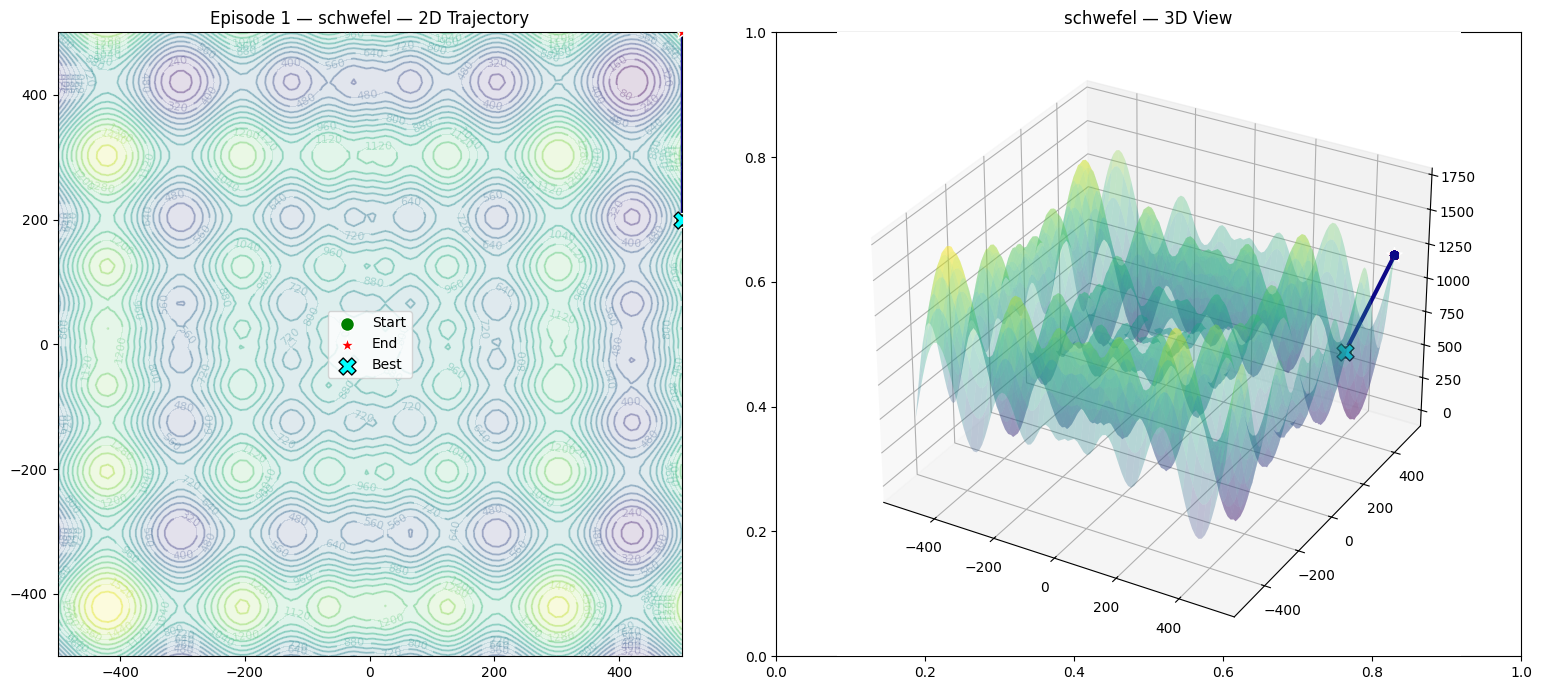

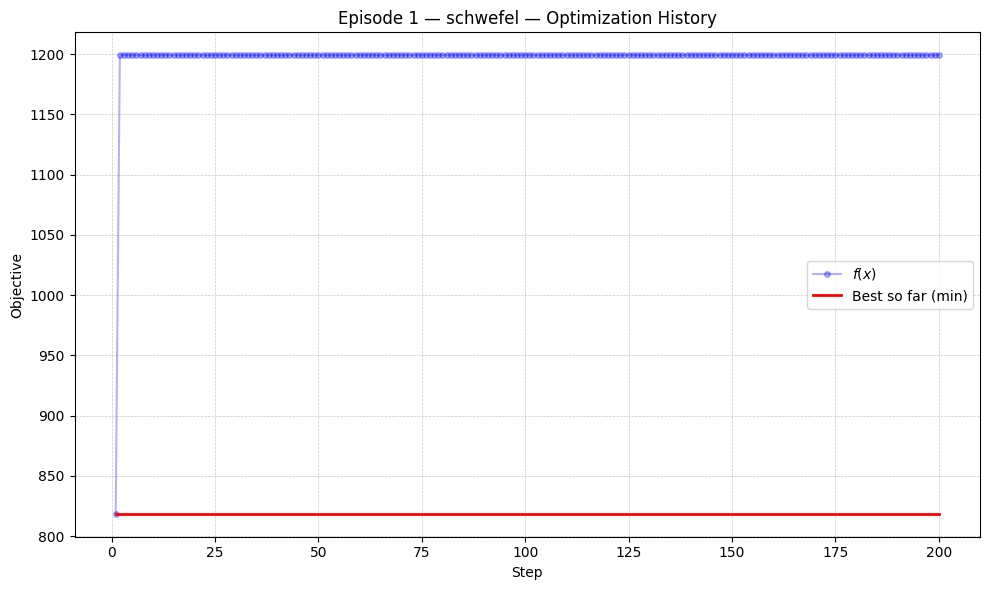

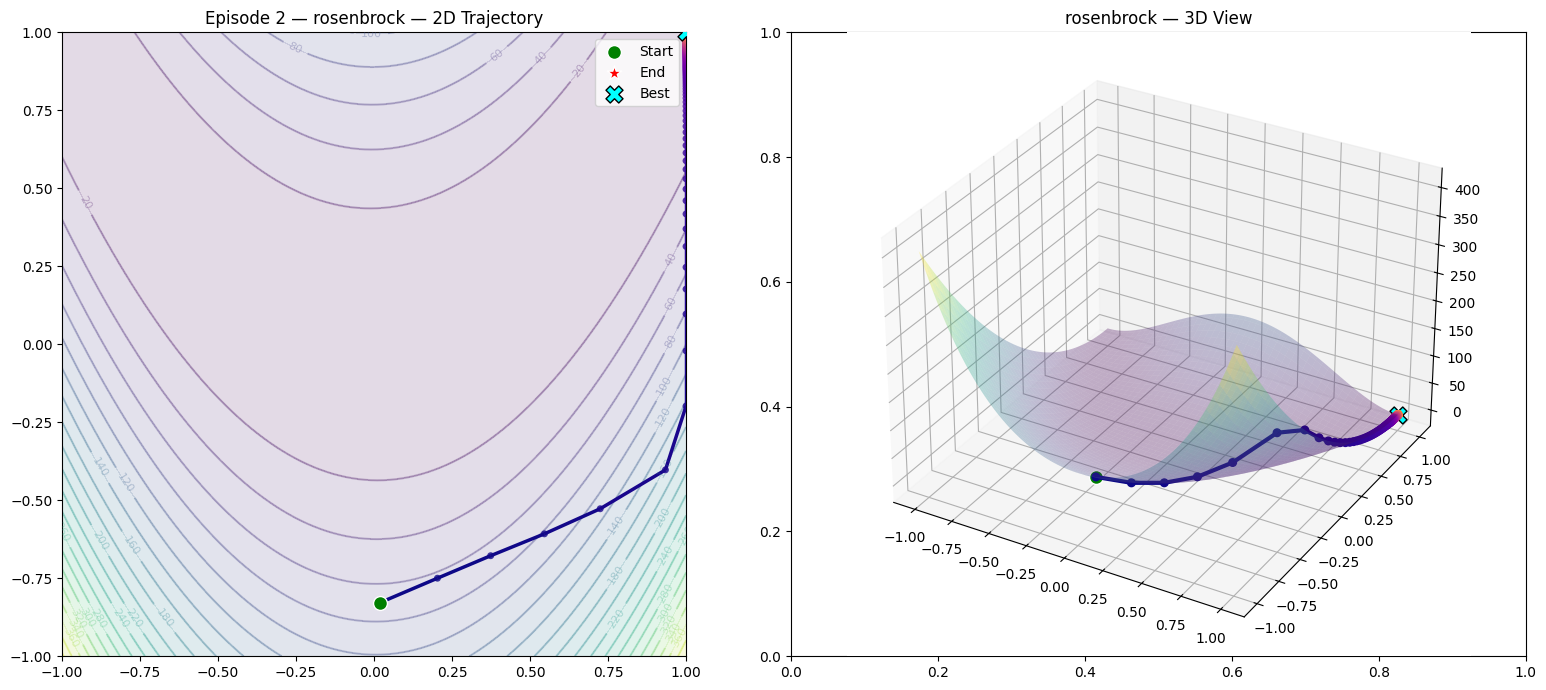

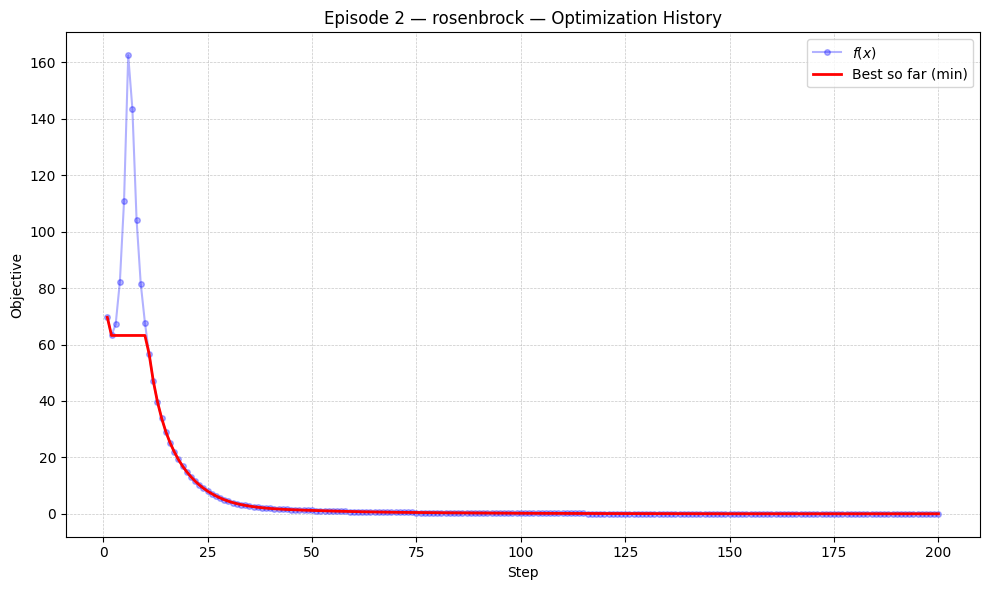

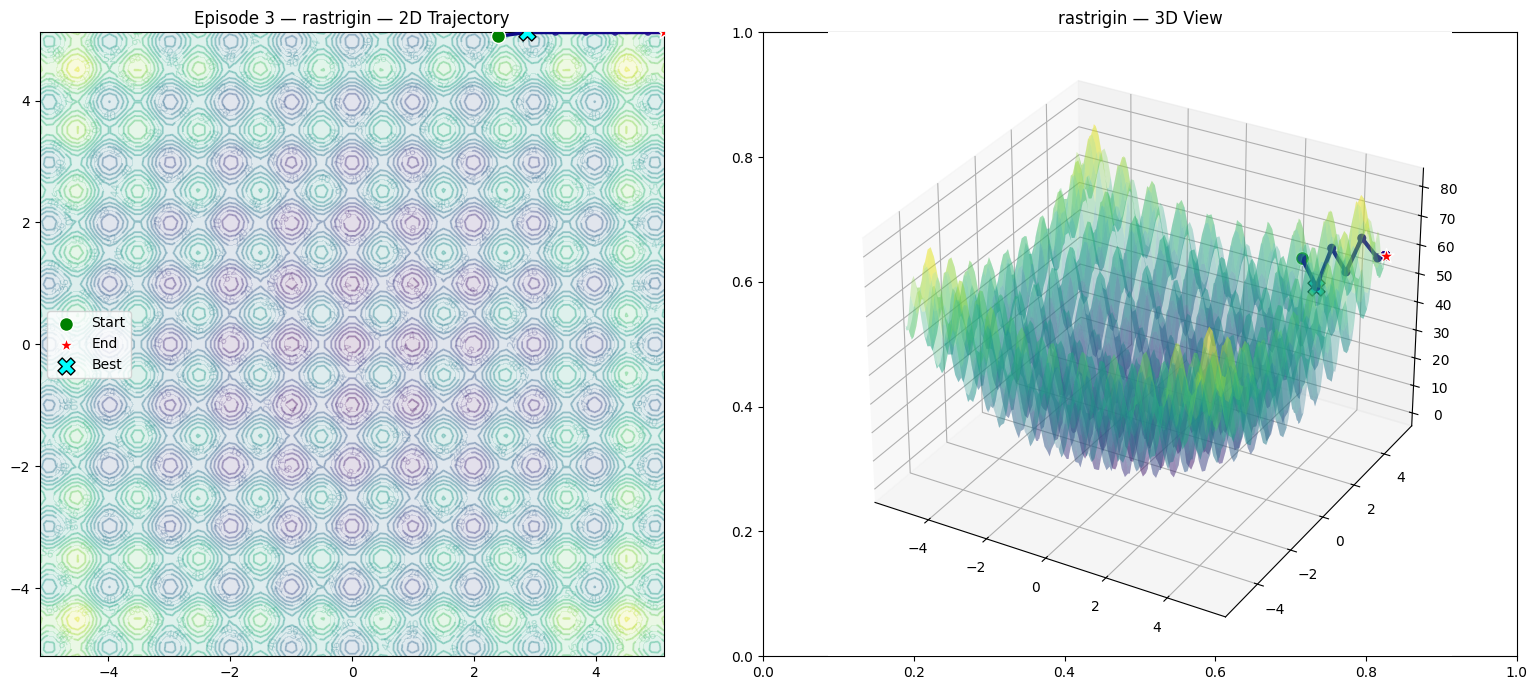

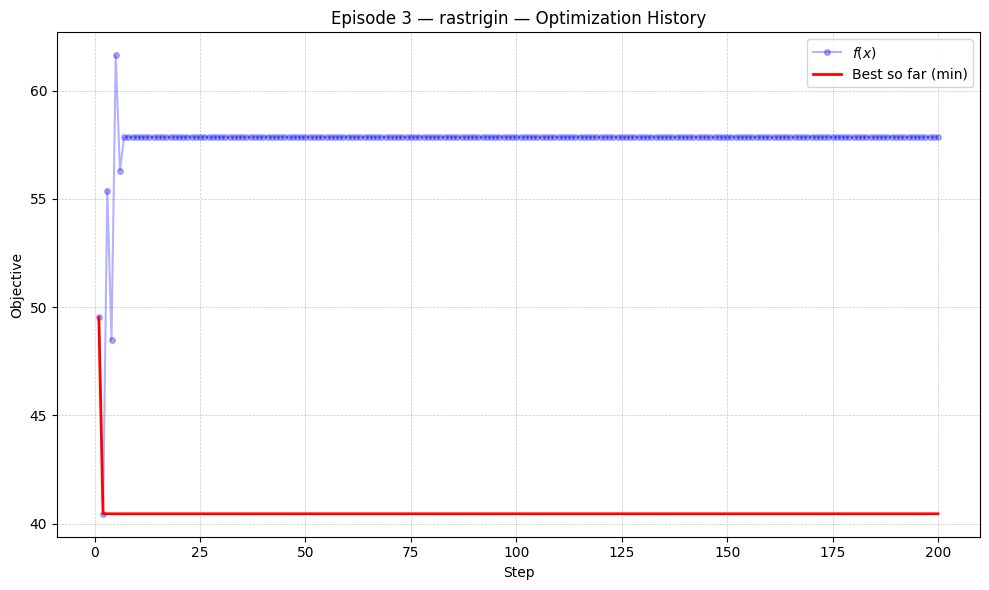

In [45]:
# ── SAC Inference ──────────────────────────────────────────────────────
run_inference(sac_algo, n_episodes=3)

In [22]:
# ── Cleanup (вызывать только когда полностью закончил) ─────────────────
ppo_algo.stop()
sac_algo.stop()
ray.shutdown()
print("All algorithms stopped. Ray shutdown complete.")

(SingleAgentEnvRunner pid=24884) rastrigin: dims=2, bounds=(-5.12, 5.12), opt=0.000000 [repeated 15x across cluster]
(SingleAgentEnvRunner pid=24884) rosenbrock: dims=2, bounds=(-1.0, 1.0), opt=0.000000 [repeated 15x across cluster]
(SingleAgentEnvRunner pid=24884) schwefel: dims=2, bounds=(-500.0, 500.0), opt=0.000000 [repeated 15x across cluster]
(SingleAgentEnvRunner pid=24884) [SequentialBackend] New shuffle order: rosenbrock, schwefel, rastrigin [repeated 4x across cluster]
(SingleAgentEnvRunner pid=24884) SequentialBackend: 3 backends (rastrigin, rosenbrock, schwefel), mode=shuffle [repeated 15x across cluster]
(SingleAgentEnvRunner pid=24884) [SequentialBackend] New shuffle order: rosenbrock, rastrigin, schwefel [repeated 5x across cluster]
(SingleAgentEnvRunner pid=24884) [SequentialBackend] New shuffle order: schwefel, rastrigin, rosenbrock [repeated 5x across cluster]


(SingleAgentEnvRunner pid=25364) DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `RLModule(observation_space=.., action_space=.., inference_only=.., model_config=.., catalog_class=..)` instead. This will raise an error in the future!


All algorithms stopped. Ray shutdown complete.


## CartPole — SAC (Discrete)

Классический бенчмарк `CartPole-v1` (дискретное действие: 0 или 1).  
RLlib SAC нативно поддерживает discrete actions.

- **Сеть**: `[256, 256]`, relu
- **gamma**: 0.99, **tau**: 0.005, **auto-alpha** (target_entropy = 0.98 * -log(1/2))
- **replay_buffer**: 50k, **batch**: 256, **n_step**: 1
- **GradientMonitorCallback** логирует статистику градиентов каждые 5 итераций

In [31]:
# ── CartPole SAC Config ─────────────────────────────────────────────────

ray.init(ignore_reinit_error=True)

cartpole_sac_config = (
    SACConfig()
    .environment(
        env="CartPole-v1",
    )
    .env_runners(
        num_env_runners=2,
        num_envs_per_env_runner=4,     # 2*4 = 8 параллельных сред
        rollout_fragment_length="auto",
    )
    .training(
        gamma=0.99,
        tau=0.005,
        initial_alpha=1.0,
        target_entropy="auto",
        actor_lr=3e-4,
        critic_lr=3e-4,
        alpha_lr=3e-4,
        n_step=1,
        train_batch_size_per_learner=256,
        twin_q=True,
        replay_buffer_config={
            "type": "PrioritizedEpisodeReplayBuffer",
            "capacity": 50_000,
        },
        num_steps_sampled_before_learning_starts=1000,
        #grad_clip=0.5,
    )
    .rl_module(
        model_config=DefaultModelConfig(
            fcnet_hiddens=[256, 256],
            fcnet_activation="relu",
        ),
    )
    .learners(num_learners=0)
    .callbacks(GradientMonitorCallback)
    .reporting(
        min_sample_timesteps_per_iteration=1000,  # ≥ 1000 env steps per train() call
        min_time_s_per_iteration=0,
    )
)

cartpole_sac_algo = cartpole_sac_config.build_algo()
print("CartPole SAC algo built successfully")

2026-03-05 21:29:06,719	INFO worker.py:1831 -- Calling ray.init() again after it has already been called.
2026-03-05 21:29:06,722	WARNING sac.py:491 -- You are running SAC on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False, enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
c:\Users\cool4\AppData\Local\Programs\Python\Python312\Lib\site-packages\ray\rllib\algorithms\algorithm.py:527: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
c:\Users\cool4\AppData\Local\Programs\Python\Python312\Lib\site-packages\ray\tune\logger\unified

CartPole SAC algo built successfully


In [32]:
# ── CartPole SAC Training ───────────────────────────────────────────────
# Каждая итерация = ~1000 env steps → несколько завершённых эпизодов
cartpole_sac_algo = train_and_report(cartpole_sac_algo, n_iters=50, dump_first=True)

[GradMonitor] Hooks on 18 params
TOP KEYS: ['timers', 'env_runners', 'num_training_step_calls_per_iteration', 'replay_buffer', 'learners', 'num_env_steps_sampled_lifetime', 'fault_tolerance', 'env_runner_group', 'done', 'training_iteration', 'trial_id', 'date', 'timestamp', 'time_this_iter_s', 'time_total_s', 'pid', 'hostname', 'node_ip', 'config', 'time_since_restore', 'iterations_since_restore', 'perf']
  env_runners/module_to_env_connector: ['timers', 'connector_pipeline_timer']
  env_runners/num_env_steps_sampled_lifetime = 1000.0
  env_runners/num_module_steps_sampled_lifetime: ['default_policy']
  env_runners/num_env_steps_sampled = 1000
  env_runners/num_episodes = 41
  env_runners/sample = 0.004677421491482835
  env_runners/env_to_module_sum_episodes_length_in = 3.8126315789473684
  env_runners/env_reset_timer = 0.000993249996099621
  env_runners/num_agent_steps_sampled: ['default_agent']
  env_runners/env_step_timer = 0.00022533169031559833
  env_runners/env_to_module_connecto

[CartPole Inference ep 1] reward=136
[CartPole Inference ep 2] reward=257
[CartPole Inference ep 3] reward=207
[CartPole Inference ep 4] reward=149
[CartPole Inference ep 5] reward=220
[CartPole Inference ep 6] reward=143
[CartPole Inference ep 7] reward=162
[CartPole Inference ep 8] reward=147
[CartPole Inference ep 9] reward=206
[CartPole Inference ep 10] reward=182


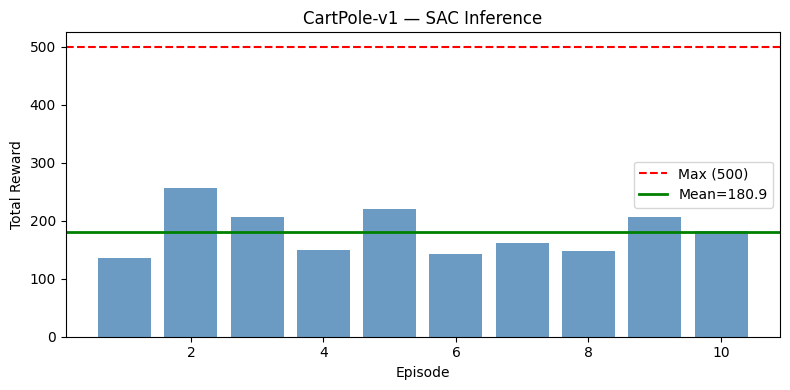

In [33]:
# ── CartPole SAC Inference ──────────────────────────────────────────────
import gymnasium as gym
import matplotlib.pyplot as plt


def run_cartpole_inference(algo, n_episodes: int = 5):
    """Прогоняет CartPole эпизоды, печатает reward и строит график."""
    env = gym.make("CartPole-v1")

    has_rl_module = hasattr(algo, "get_module")
    if has_rl_module:
        rl_module = algo.get_module()
        if hasattr(rl_module, "eval"):
            rl_module.eval()

    episode_rewards = []

    for ep in range(n_episodes):
        obs, info = env.reset()
        total_reward = 0.0
        done = False

        while not done:
            if has_rl_module:
                import torch as _torch
                with _torch.no_grad():
                    obs_t = _torch.tensor(obs, dtype=_torch.float32).unsqueeze(0)
                    out = rl_module.forward_inference({"obs": obs_t})
                    action = out["action_dist_inputs"].argmax(dim=-1).item()
            else:
                action = algo.compute_single_action(obs, explore=False)

            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            done = terminated or truncated

        episode_rewards.append(total_reward)
        print(f"[CartPole Inference ep {ep+1}] reward={total_reward:.0f}")

    env.close()

    # ── График rewards ───
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(range(1, n_episodes + 1), episode_rewards, color="steelblue", alpha=0.8)
    ax.axhline(y=500, color="red", linestyle="--", label="Max (500)")
    ax.axhline(y=np.mean(episode_rewards), color="green", linestyle="-", linewidth=2,
               label=f"Mean={np.mean(episode_rewards):.1f}")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Total Reward")
    ax.set_title("CartPole-v1 — SAC Inference")
    ax.legend()
    plt.tight_layout()
    plt.show()

    return episode_rewards


cartpole_rewards = run_cartpole_inference(cartpole_sac_algo, n_episodes=10)

In [8]:
# ── Cleanup CartPole SAC ────────────────────────────────────────────────
cartpole_sac_algo.stop()
print("CartPole SAC stopped.")

CartPole SAC stopped.


## CartPole — PPO (Discrete)

- **Сеть**: `[256, 256]`, relu
- **gamma**: 0.99, **lambda**: 0.95, **clip_param**: 0.2
- **entropy_coeff**: 0.01, **grad_clip**: 0.5, **lr**: 3e-4
- **train_batch**: 4000, **minibatch**: 64, **sgd_iters**: 10
- **GradientMonitorCallback** каждые 5 итераций

In [41]:
# ── CartPole PPO Config ──────────────────────────────────────────────────

ray.init(ignore_reinit_error=True)

cartpole_ppo_config = (
    PPOConfig()
    .environment(
        env="CartPole-v1",
    )
    .env_runners(
        num_env_runners=2,
        num_envs_per_env_runner=4,
        rollout_fragment_length="auto",
    )
    .training(
        gamma=0.99,
        lambda_=0.95,
        lr=3e-4,
        entropy_coeff=0.01,
        vf_loss_coeff=0.5,
        #clip_param=None,
        grad_clip=None,
        train_batch_size_per_learner=4000,
        minibatch_size=64,
        num_epochs=10,
        use_gae=True,
        use_critic=True,
    )
    .rl_module(
        model_config=DefaultModelConfig(
            fcnet_hiddens=[256, 256],
            fcnet_activation="relu",
            vf_share_layers=False,
        ),
    )
    .learners(num_learners=0)
    .callbacks(GradientMonitorCallback)
    .reporting(
        min_sample_timesteps_per_iteration=4000,
        min_time_s_per_iteration=0,
    )
)

cartpole_ppo_algo = cartpole_ppo_config.build_algo()
print("CartPole PPO algo built successfully")

2026-03-05 23:54:48,052	INFO worker.py:1831 -- Calling ray.init() again after it has already been called.
2026-03-05 23:54:58,210	INFO trainable.py:161 -- Trainable.setup took 10.146 seconds. If your trainable is slow to initialize, consider setting reuse_actors=True to reduce actor creation overheads.
2026-03-05 23:54:58,214	WARNING util.py:62 -- Install gputil for GPU system monitoring.


CartPole PPO algo built successfully


In [42]:
# ── CartPole PPO Training ────────────────────────────────────────────────
cartpole_ppo_algo = train_and_report(cartpole_ppo_algo, n_iters=50)

[GradMonitor] Hooks on 12 params
[  1/50] ret=+23.6  len=24  L=2.143 π=-0.174 Q=4.637  best=+23.6  
[  2/50] ret=+40.9  len=41  L=3.223 π=-0.042 Q=6.526  best=+40.9  |g|=0.419
[  3/50] ret=+95.0  len=95  L=1.887 π=-0.055 Q=3.883  best=+95.0  |g|=0.667
[  4/50] ret=+165.6  len=166  L=1.074 π=-0.221 Q=2.594  best=+165.6  |g|=0.838
  [grad] iter 5 | 629 bwd | norm=0.9640 max=4.7477
[  5/50] ret=+243.4  len=243  L=1.653 π=0.059 Q=3.191  best=+243.4  |g|=0.964
[  6/50] ret=+312.5  len=313  L=1.191 π=0.019 Q=2.352  best=+312.5  |g|=1.072
[  7/50] ret=+311.0  len=311  L=1.417 π=-0.154 Q=3.149  best=+312.5  |g|=1.173
[  8/50] ret=+287.4  len=287  L=1.321 π=-0.180 Q=3.008  best=+312.5  |g|=1.449
[  9/50] ret=+358.6  len=359  L=1.047 π=-0.139 Q=2.381  best=+358.6  |g|=1.720
  [grad] iter 10 | 629 bwd | norm=1.5556 max=7.6411
[ 10/50] ret=+353.5  len=353  L=1.881 π=-0.096 Q=3.963  best=+358.6  |g|=1.556
[ 11/50] ret=+485.9  len=486  L=1.716 π=-0.015 Q=3.471  best=+485.9  |g|=1.593
[ 12/50] ret=+3

[CartPole Inference ep 1] reward=500
[CartPole Inference ep 2] reward=500
[CartPole Inference ep 3] reward=500
[CartPole Inference ep 4] reward=479
[CartPole Inference ep 5] reward=500
[CartPole Inference ep 6] reward=500
[CartPole Inference ep 7] reward=500
[CartPole Inference ep 8] reward=500
[CartPole Inference ep 9] reward=500
[CartPole Inference ep 10] reward=500


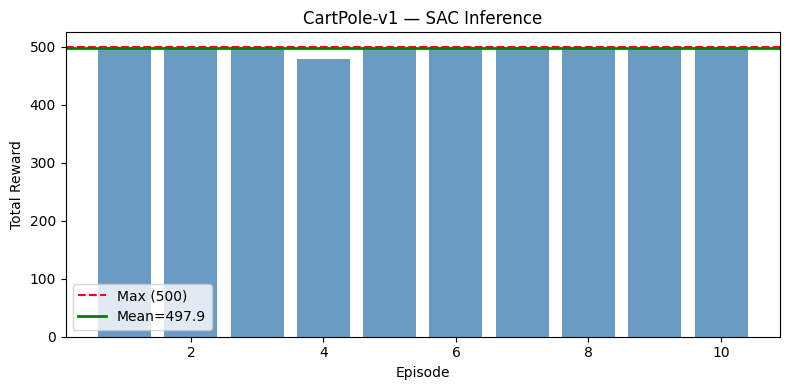

In [36]:
# ── CartPole PPO Inference ───────────────────────────────────────────────
cartpole_ppo_rewards = run_cartpole_inference(cartpole_ppo_algo, n_episodes=10)

In [37]:
# ── Cleanup CartPole PPO ─────────────────────────────────────────────────
cartpole_ppo_algo.stop()
print("CartPole PPO stopped.")

CartPole PPO stopped.
